# Chapter 10 — Fusing geometries

*Companion notebook to **The Learned Kernel**, Ch. 10. Run top to bottom.*

Chapter 9 found the spectral kernel and the tree leaf kernel **complementary**: the spectral
kernel owns smooth/periodic/high-order structure, the tree owns sharp axis-aligned thresholds,
and a real dataset carries some of each. So you do not *pick* — you **fuse**, and let the data
weigh the geometries on a held-out fold.

Fusion shows up at **two levels**, and we build both:
1. **Within a geometry** — the spectral kernel is itself a convex mixture of *H* Laplace banks
   at different bandwidths; learning the bank weights is fusion of *scales*.
2. **Across geometries** — blend that spectral kernel with a **tuned CatBoost** leaf kernel on
   a simplex. Same mechanism, one level up.

**The frame** — *what is learned · how scored · what you read off.* What: a point on the simplex
(channel weights) plus one ridge. Scored: leakage-free query-fold risk (Ch. 7) — every channel
fit on the support fold, the weights chosen on a held-out query fold. Read off: the earned
weights and the per-channel **shares**, via an *exact* additive decomposition of the fit.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import set_style
from lkbook.chapters import ch10

set_style()

## 10.1  Fit the fusion on Bike Sharing

Two channels: the **tuned CatBoost** tree (raw features) and the **spectral-Laplace** kernel
(cyclical hour/month/weekday Fourier-encoded so a periodic kernel can see the cycles). Each is
fit on the support fold; the cross-geometry weights and the ridge are selected on the held-out
query fold. We run a single seed live (the book averages settings over a larger train set).

In [3]:
bike = ch10.run_bikeshare(n_train=1200)        # one leakage-free fit, single seed
print("cross-geometry weights :", {k: round(v, 3) for k, v in bike["weights"].items()})
print("fused R^2              :", round(bike["fused_r2"], 4))
print("pure-channel R^2       :", {k: round(v, 4) for k, v in bike["single_r2"].items()})
print("component shares rho_c :", {k: round(v, 3) for k, v in bike["shares"].items()})
# The tuned tree (a strong stand-alone model) earns only a sliver: given the spectral channel,
# more tree weight raises query error. The fused R^2 edges the best single channel.

/home/asudjianto/cluster/spark-venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


cross-geometry weights : {'tree': 0.1, 'spectral': 0.9}
fused R^2              : 0.9326
pure-channel R^2       : {'tree': 0.9183, 'spectral': 0.9309}
component shares rho_c : {'tree': 0.16, 'spectral': 0.84}


## 10.2  Level one — fusion *within* the spectral kernel

The spectral channel is a convex mixture of *H* Laplace banks at learned bandwidths `T_h` with
learned simplex weights `w_h` — fusion of *scales* inside one kernel (Ch. 8). This is the same
convex-mixture move we make across geometries, one level down. The mass concentrates on the
broadest bank, with finer banks filling in.

In [4]:
bw, bT = bike["bank_weights"], bike["bank_T"]
print("spectral bank fusion (within the spectral kernel):")
for i, (w, T) in enumerate(zip(bw, bT), 1):
    print(f"   bank {i}:  weight w_h = {w:.3f}   bandwidth T_h = {T:.3f}")
# Fusing banks is a *range* axis, not an order axis (Ch. 9): the Aronszajn sum is a union of
# function spaces, so it costs sqrt(log H / n) and raises no interaction order.

spectral bank fusion (within the spectral kernel):
   bank 1:  weight w_h = 0.103   bandwidth T_h = 0.500
   bank 2:  weight w_h = 0.037   bandwidth T_h = 1.442
   bank 3:  weight w_h = 0.566   bandwidth T_h = 4.160
   bank 4:  weight w_h = 0.293   bandwidth T_h = 12.000


## 10.3  The kernels and their mixture are PSD with unit diagonal

Each channel block is symmetric PSD with a unit diagonal, so any convex mixture is too — which
is what keeps the ridge `lambda` identifiable (Ch. 3 scale degeneracy).

In [5]:
fm = bike["model"]
Xs = {ch.name: fm.Xs_by[ch.name] for ch in fm.channels}
for ch in fm.channels:
    K = ch.block(Xs[ch.name], Xs[ch.name])
    print(f"{ch.name:9s}: diag mean {np.diag(K).mean():.3f}, "
          f"min eig {np.linalg.eigvalsh((K + K.T) / 2).min():.2e}  (>= 0 => PSD)")
Kmix = ch10.mix_n([ch.block(Xs[ch.name], Xs[ch.name]) for ch in fm.channels], fm.w)
print(f"mixture  : diag mean {np.diag(Kmix).mean():.3f}, "
      f"min eig {np.linalg.eigvalsh((Kmix + Kmix.T) / 2).min():.2e}")

tree     : diag mean 1.000, min eig 2.57e-03  (>= 0 => PSD)
spectral : diag mean 1.000, min eig 3.34e-02  (>= 0 => PSD)


mixture  : diag mean 1.000, min eig 3.35e-02


## 10.4  The exact additive decomposition

Model `y = sum_c g_c + noise` with independent priors `g_c ~ N(0, alpha_c K_c)`. Each
component's posterior mean is `g_c = alpha_c K_c (K_alpha + lambda I)^{-1} y`, and the
components sum to the fused fit **exactly**. Take one held-out hour and decompose it.

In [6]:
print(f"intercept              : {bike['intercept']:.4f}")
print(f"tree contribution      : {bike['decomp']['tree']:+.4f}")
print(f"spectral contribution  : {bike['decomp']['spectral']:+.4f}")
recon = bike["intercept"] + sum(bike["decomp"].values())
print(f"reconstruction sum     : {recon:.6f}")
print(f"model prediction       : {bike['pred0']:.6f}")
assert abs(recon - bike["pred0"]) < 1e-6      # exact, not approximate
print("=> components reconstruct the prediction to machine precision")

intercept              : 4.5366
tree contribution      : +0.0421
spectral contribution  : -2.2061
reconstruction sum     : 2.372641
model prediction       : 2.372641
=> components reconstruct the prediction to machine precision


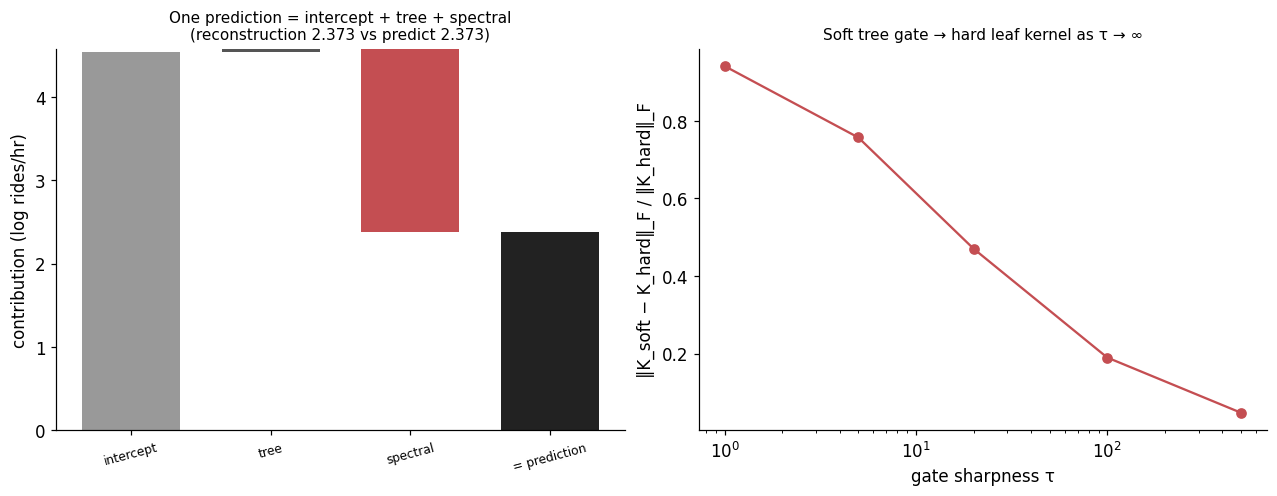

In [7]:
ch10.make_decomposition_figure(bike=bike)
plt.show()

## 10.5  Fusion is **not** output-averaging

Averaging applies *M* independently-inverted ridge smoothers and combines the outputs; fusion
applies *one* ridge to the summed kernel. Since the ridge filter `g(t)=t/(t+lambda)` is
operator-concave, matrix Jensen gives the Loewner domination `S_fuse >= S_avg`: the fused
smoother passes at least as much of every eigendirection. On a smooth-plus-sharp synthetic
target the fused predictor beats averaging.

In [8]:
X, y = ch10.smooth_to_sharp(0.5)
n = len(y); perm = np.random.RandomState(7).permutation(n); nte = n // 4
te, tr = perm[:nte], perm[nte:]
fa = ch10.fusion_vs_averaging(ch10.same_reps(X[tr], ["tree", "spectral"]), y[tr],
                              ch10.same_reps(X[te], ["tree", "spectral"]), y[te])
print(f"min eig of (S_fuse - S_avg): {fa['eig_min']:.2e}   (>= 0 => Loewner domination)")
print(f"fused   test RMSE          : {fa['fused_rmse']:.4f}")
print(f"averaged test RMSE         : {fa['avg_rmse']:.4f}")

min eig of (S_fuse - S_avg): 6.26e-10   (>= 0 => Loewner domination)
fused   test RMSE          : 0.4361
averaged test RMSE         : 0.4526


## 10.6  Soft tree gates → the hard leaf kernel as τ → ∞

The hard leaf kernel is a step function of the thresholds — no gradient. Replace each split by a
sigmoid gate of sharpness τ; a leaf's membership is the path-conjunction product. As τ → ∞ the
soft co-membership kernel converges to the exact leaf kernel, so finite τ is a differentiable
relaxation around the hard anchor — the bridge to learning the tree geometry end to end.

In [9]:
fid = ch10.soft_tree_fidelity()
for tau, gap in fid:
    print(f"  tau = {tau:4d}   ||K_soft - K_hard||_F / ||K_hard||_F = {gap:.4f}")

  tau =    1   ||K_soft - K_hard||_F / ||K_hard||_F = 0.9415
  tau =    5   ||K_soft - K_hard||_F / ||K_hard||_F = 0.7572
  tau =   20   ||K_soft - K_hard||_F / ||K_hard||_F = 0.4705
  tau =  100   ||K_soft - K_hard||_F / ||K_hard||_F = 0.1896
  tau =  500   ||K_soft - K_hard||_F / ||K_hard||_F = 0.0472


## 10.7  Explore: the earned weight tracks the target's geometry

Drive a synthetic target from smooth/periodic (t = 0) to a deep axis-aligned partition (t = 1,
the geometry the tree owns) and refit the fusion at each step. Nobody sets the weights — the
query fold does. Watch the selected vertex slide from spectral to tree.

In [10]:
sweep = ch10.vertex_sweep(ts=(0.0, 0.25, 0.5, 0.75, 1.0), n_fit=900)
tbl = pd.DataFrame(sweep)[["t", "spectral", "tree"]].round(2)
tbl

,t,spectral,tree
0,0.00,1.0,0.0
1,0.25,0.9,0.1
2,0.50,0.1,0.9
3,0.75,0.0,1.0
4,1.00,0.0,1.0


In [11]:
from ipywidgets import interact, FloatSlider

_by_t = {round(r["t"], 2): r for r in sweep}


def show_weights(t=0.0):
    r = _by_t[round(t, 2)]
    fig, ax = plt.subplots(figsize=(5.2, 4.0), constrained_layout=True)
    ax.bar(["spectral", "tree"], [r["spectral"], r["tree"]],
           color=[ch10.SPECTRAL_C, ch10.TREE_C])
    ax.set_ylim(0, 1.02); ax.set_ylabel("earned simplex weight")
    ax.set_title(f"target morph t = {t:.2f}\n(0 = smooth/periodic → 1 = sharp partition)",
                 fontsize=11)
    plt.show()


interact(show_weights, t=FloatSlider(min=0.0, max=1.0, step=0.25, value=0.0,
                                     description="morph t"));

interactive(children=(FloatSlider(value=0.0, description='morph t', max=1.0, step=0.25), Output()), _dom_class…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the fused fit is decomposed *exactly*. Sum the per-channel contributions plus
the intercept on a batch of held-out rows and compare to `fm.predict`.

In [12]:
# TODO: build reps for the first few test rows, call fm.channel_contributions, and check the sum
recon = pred = None
print(recon, pred)

None None


<details><summary>Solution</summary>

```python
from lkbook import load_bikeshare
d = load_bikeshare()
_, reps_te, _ = ch10._bike_reps(d)
reps5 = {nm: reps_te[nm][:5] for nm in fm.names}
contribs, intercept = fm.channel_contributions(reps5)
recon = intercept + sum(np.atleast_1d(v) for v in contribs.values())
pred = fm.predict(reps5)
print(np.max(np.abs(recon - pred)))   # ~1e-13: the decomposition IS the model
```
The components are Gaussian posterior means whose sum is `K_alpha (K_alpha + lambda I)^{-1} y`,
the fused smoother applied to `y` — so they reconstruct the prediction exactly, not approximately.
</details>

**(⋆)** Verify the Loewner domination is **strict** at an interior mixture but an **equality**
at a vertex. Re-run `fusion_vs_averaging` with `w=[1.0, 0.0]` (a vertex) and confirm the min
eigenvalue of `S_fuse - S_avg` is ~0 there, while it is also >= 0 at the interior `w=[0.5,0.5]`.

In [13]:
# TODO: call ch10.fusion_vs_averaging twice with different w and compare eig_min
eig_vertex = eig_interior = None
print(eig_vertex, eig_interior)

None None


<details><summary>Solution</summary>

```python
args = (ch10.same_reps(X[tr], ["tree", "spectral"]), y[tr],
        ch10.same_reps(X[te], ["tree", "spectral"]), y[te])
eig_vertex   = ch10.fusion_vs_averaging(*args, w=[1.0, 0.0])["eig_min"]
eig_interior = ch10.fusion_vs_averaging(*args, w=[0.5, 0.5])["eig_min"]
print(f"vertex {eig_vertex:.2e}   interior {eig_interior:.2e}")
# at a vertex S_fuse and S_avg coincide (a single channel), so the gap is exactly 0;
# at an interior point the operator-concavity inequality is strict (>= 0, generically > 0).
```
`g(t) = t/(t+lambda)` is operator-concave, so `g(sum_c w_c K_c) >= sum_c w_c g(K_c)` in the
Loewner order, with equality only when the combination is degenerate (a vertex) or the kernels
coincide. Averaging the *fits* throws away the cross-kernel similarity the *fused* kernel keeps.
</details>

---
*Companion to Chapter 10 of **The Learned Kernel**. Everything here comes from
`lkbook.chapters.ch10` — the same code the book's figures come from. The tree channel is a
hyperparameter-tuned CatBoost read as the Ch. 4 leaf kernel; the spectral channel reuses Ch. 8's
learned spectral-Laplace kernel (`ch08.fit_spectral`, learned mode). The book reports the Bike
Sharing fit on a larger train set; here we run a single seed on a smaller sample live, so the
exact weights may differ by a grid step.*